# Lab 4: Quantum Amplitude Estimation (QAE)

> **Motivating question:** If a problem is really about estimating a probability or an average, can a quantum computer do better than plain Monte Carlo sampling?

**Learning goals**

- explain how a probability or expectation can be encoded into a quantum amplitude
- connect Grover-style rotations to the amplitude-estimation formula
- see why phase estimation appears inside canonical QAE
- compare a classical Monte Carlo baseline with a small, fully worked QAE toy workflow
- understand both the promised scaling advantage and the practical caveats

**Notebook roadmap**

1. Why estimation is the bottleneck
2. A tiny classical baseline
3. Encoding a probability into an amplitude
4. Grover rotation geometry
5. Why phase estimation reveals the amplitude
6. Full toy QAE on a one-qubit example
7. Finite-scenario QAE for a small safety-estimation problem
8. Encoding expectations, not only binary success
9. Summary and practical interpretation

This lab follows directly after the QFT and QPE material from Lab 3. The central idea is that **QAE uses phase estimation on a Grover-style rotation operator** in order to recover an unknown amplitude.

In [1]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.mpl-cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector

from utilities.complexity_utils import COLORS, setup_lecture_style

setup_lecture_style()
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlepad'] = 10
np.set_printoptions(precision=4, suppress=True)

## 1. Why Estimation Is the Bottleneck

**Concept question:** Why does amplitude estimation matter at all?

Many useful computational tasks are not really "search" problems or "optimization" problems at the final step. They are **estimation** problems:

- What is the probability that a path is collision-free?
- What fraction of scenarios satisfy a safety constraint?
- What is the expected value of a bounded score?

Classically, a direct baseline is Monte Carlo sampling. If the target quantity is an average with additive error $\varepsilon$, standard Monte Carlo needs on the order of

$$
N = O\!\left(\frac{1}{\varepsilon^2}\right)
$$

samples.

Under ideal oracle assumptions, canonical QAE improves the query scaling to

$$
M = O\!\left(\frac{1}{\varepsilon}\right).
$$

That is the main theoretical attraction. The hard part is that the quantum computer must first encode the estimation problem into amplitudes and implement the required reflections coherently.

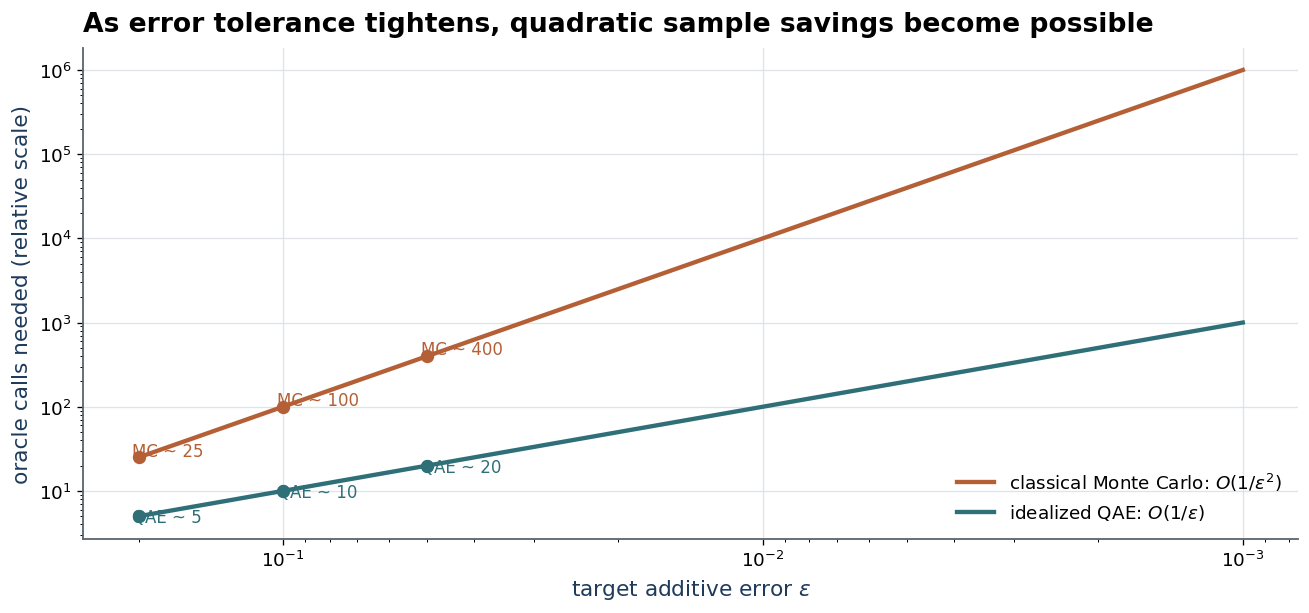

In [2]:
epsilons = np.logspace(-3, -0.7, 250)
monte_carlo_queries = 1 / epsilons**2
ideal_qae_queries = 1 / epsilons

fig, ax = plt.subplots(figsize=(10.8, 5.0), constrained_layout=True)
ax.loglog(epsilons, monte_carlo_queries, color=COLORS['rust'], label=r'classical Monte Carlo: $O(1/\varepsilon^2)$')
ax.loglog(epsilons, ideal_qae_queries, color=COLORS['teal'], label=r'idealized QAE: $O(1/\varepsilon)$')
ax.invert_xaxis()
ax.set_xlabel(r'target additive error $\varepsilon$')
ax.set_ylabel('oracle calls needed (relative scale)')
ax.set_title('As error tolerance tightens, quadratic sample savings become possible', loc='left')
ax.legend(loc='lower right')

for epsilon in [0.2, 0.1, 0.05]:
    mc = 1 / epsilon**2
    qae = 1 / epsilon
    ax.scatter([epsilon], [mc], color=COLORS['rust'])
    ax.scatter([epsilon], [qae], color=COLORS['teal'])
    ax.text(epsilon * 1.03, mc * 1.05, f'MC ~ {mc:.0f}', color=COLORS['rust'], fontsize=10)
    ax.text(epsilon * 1.03, qae * 0.85, f'QAE ~ {qae:.0f}', color=COLORS['teal'], fontsize=10)

plt.show()

The plot is only an asymptotic guide, but it already explains why QAE appears so often in quantum finance, uncertainty quantification, and Monte Carlo-style quantum proposals.

> **Takeaway:** QAE is valuable when the real bottleneck is repeated estimation and when the quantum cost of state preparation and reversible scoring does not erase the sample-complexity gain.

## 2. A Tiny Classical Baseline

**Concept question:** What are we trying to estimate before we add any quantum machinery?

Consider a toy safety-evaluation problem with eight equally likely scenarios. A scenario is either safe (`1`) or unsafe (`0`):

$$
[0, 1, 0, 1, 0, 1, 0, 0].
$$

So the exact safety probability is

$$
a = \frac{3}{8} = 0.375.
$$

We start classically because QAE should be compared to a concrete baseline, not to vague intuition.

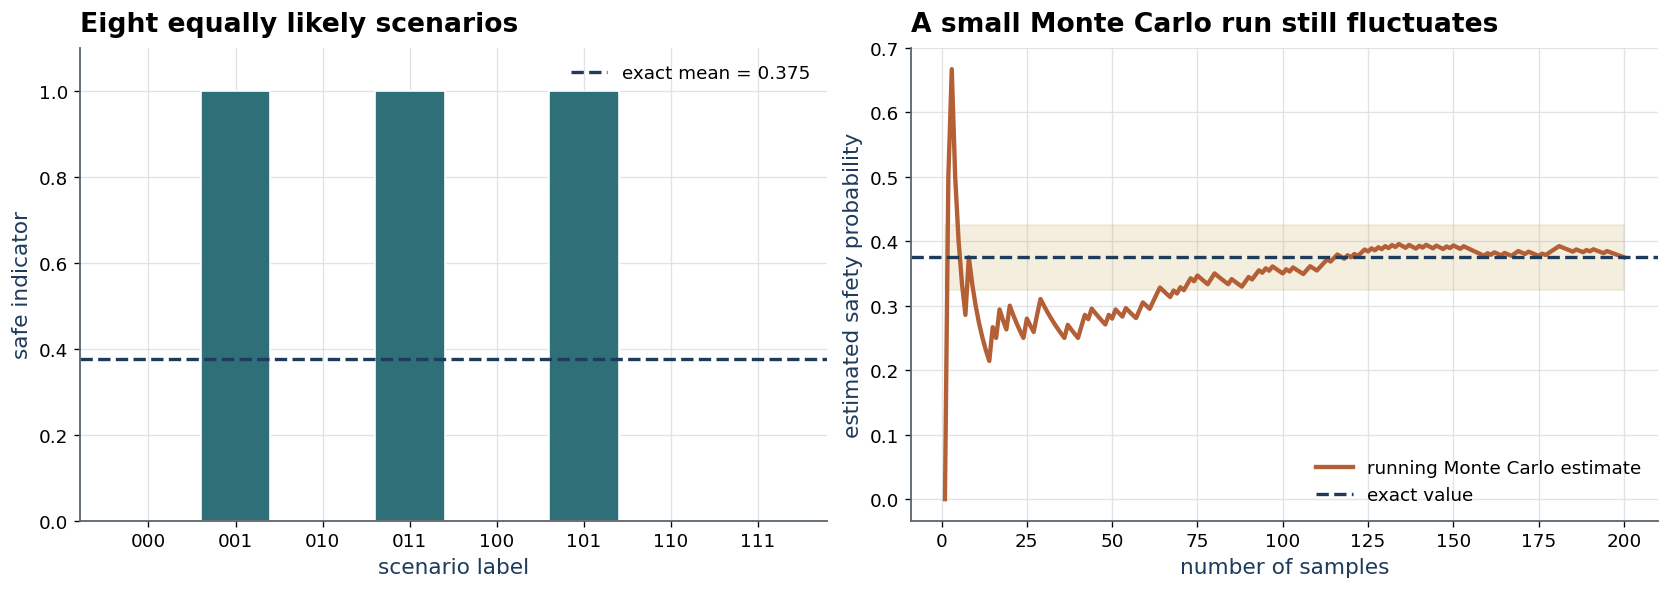

Exact safety probability: 0.375
Final 200-sample Monte Carlo estimate: 0.375


In [3]:
scenario_labels = [format(index, '03b') for index in range(8)]
safe_indicator = np.array([0, 1, 0, 1, 0, 1, 0, 0], dtype=int)
exact_probability = safe_indicator.mean()

rng = np.random.default_rng(7)
num_samples = 200
sampled_scenarios = rng.integers(0, len(safe_indicator), size=num_samples)
running_estimate = np.cumsum(safe_indicator[sampled_scenarios]) / np.arange(1, num_samples + 1)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), constrained_layout=True)

bar_colors = [COLORS['teal'] if value else COLORS['light_gray'] for value in safe_indicator]
axes[0].bar(scenario_labels, safe_indicator, color=bar_colors, edgecolor='white')
axes[0].axhline(exact_probability, color=COLORS['navy'], linestyle='--', linewidth=2.0, label=f'exact mean = {exact_probability:.3f}')
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel('scenario label')
axes[0].set_ylabel('safe indicator')
axes[0].set_title('Eight equally likely scenarios', loc='left')
axes[0].legend(loc='upper right')

axes[1].plot(np.arange(1, num_samples + 1), running_estimate, color=COLORS['rust'], label='running Monte Carlo estimate')
axes[1].axhline(exact_probability, color=COLORS['navy'], linestyle='--', linewidth=2.0, label='exact value')
axes[1].fill_between(np.arange(1, num_samples + 1), exact_probability - 0.05, exact_probability + 0.05, color=COLORS['gold'], alpha=0.18)
axes[1].set_xlabel('number of samples')
axes[1].set_ylabel('estimated safety probability')
axes[1].set_title('A small Monte Carlo run still fluctuates', loc='left')
axes[1].legend(loc='lower right')

plt.show()

print(f'Exact safety probability: {exact_probability:.3f}')
print(f'Final 200-sample Monte Carlo estimate: {running_estimate[-1]:.3f}')

This is the quantity the quantum algorithm should learn. The only thing QAE changes is **how the estimate is extracted**, not what the target number means.

In a real application, the scenarios might encode wind realizations, traffic disturbances, or sensor uncertainty. In this tiny lab, we keep only the estimation skeleton.

## 3. Encoding a Probability into an Amplitude

**Concept question:** How does a probability become a quantum amplitude?

The simplest teaching model uses one qubit. Prepare

$$
A|0\rangle = \cos(\theta)|0\rangle + \sin(\theta)|1\rangle.
$$

If we declare $|1\rangle$ to be the **good** state, then the good-state probability is

$$
a = \sin^2(\theta).
$$

We choose an angle with a clean binary phase later:

$$
\theta = \frac{3\pi}{16},
\qquad
 a = \sin^2\!\left(\frac{3\pi}{16}\right) \approx 0.30866.
$$

This example is tiny, but it already contains the full QAE logic.

,basis state,amplitude,probability
0,|0> (bad),0.83147+0.00000j,0.691342
1,|1> (good),0.55557+0.00000j,0.308658


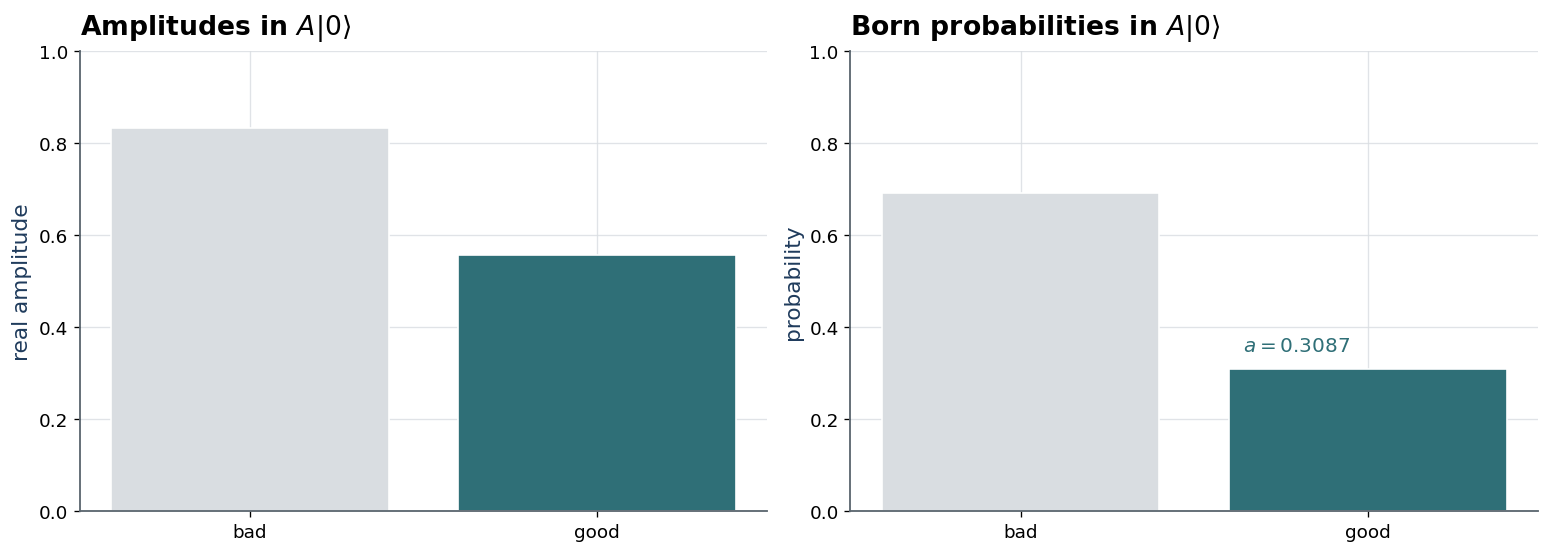

theta / pi = 0.1875
encoded amplitude a = sin^2(theta) = 0.308658


In [4]:
theta = 3 * np.pi / 16
amplitude_a = np.sin(theta) ** 2

A_toy = QuantumCircuit(1, name='A')
A_toy.ry(2 * theta, 0)

toy_state = Statevector.from_instruction(A_toy)
toy_vector = toy_state.data

toy_summary = pd.DataFrame(
    {
        'basis state': ['|0> (bad)', '|1> (good)'],
        'amplitude': toy_vector,
        'probability': np.abs(toy_vector) ** 2,
    }
)
display(toy_summary)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), constrained_layout=True)
axes[0].bar(['bad', 'good'], toy_vector.real, color=[COLORS['light_gray'], COLORS['teal']], edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('real amplitude')
axes[0].set_title(r'Amplitudes in $A|0\rangle$', loc='left')

axes[1].bar(['bad', 'good'], np.abs(toy_vector) ** 2, color=[COLORS['light_gray'], COLORS['teal']], edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('probability')
axes[1].set_title(r'Born probabilities in $A|0\rangle$', loc='left')
axes[1].text(0.95, amplitude_a + 0.04, fr'$a = {amplitude_a:.4f}$', color=COLORS['teal'], ha='right')

plt.show()

print(f'theta / pi = {theta / np.pi:.4f}')
print(f'encoded amplitude a = sin^2(theta) = {amplitude_a:.6f}')

The encoding rule is the key bridge:

- a classical probability or mean becomes an ancilla success probability,
- that success probability becomes the squared magnitude of a good amplitude,
- QAE tries to recover that amplitude faster than naive sampling.

> **Takeaway:** In amplitude estimation, the target number is not stored as a classical register value. It is stored indirectly in the geometry of a quantum state.

## 4. Grover Rotation Geometry

**Concept question:** Why do Grover-style reflections help estimation?

Define the usual reflections:

- $S_\chi$: flip the phase of good states,
- $S_0$: flip the phase of the all-zero reference state.

Then the Grover operator is

$$
Q = -A S_0 A^\dagger S_\chi.
$$

Inside the two-dimensional subspace spanned by the good and bad directions, $Q$ acts as a rotation by angle $2\theta$. Starting from $A|0\rangle$, repeated applications of $Q$ move the state around that plane in a perfectly structured way.

That structure is what phase estimation can read.

,k Grover steps,good probability,theory sin^2((2k+1)theta)
0,0,0.308658,0.308658
1,1,0.961940,0.961940
2,2,0.038060,0.038060
3,3,0.691342,0.691342
4,4,0.691342,0.691342
5,5,0.038060,0.038060


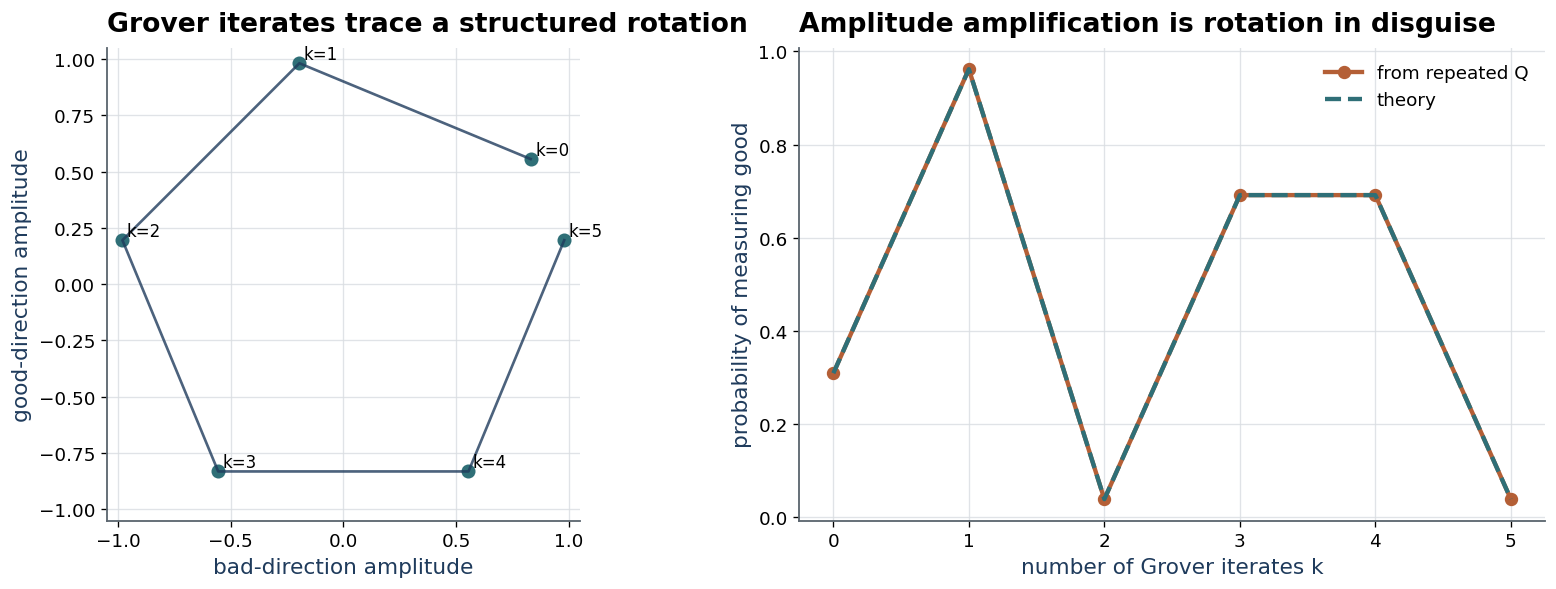

In [5]:
def grover_operator_from_state_preparation(circuit, good_qubits):
    matrix_a = Operator(circuit).data
    num_qubits = circuit.num_qubits
    dimension = 2**num_qubits

    s_zero = np.eye(dimension, dtype=complex)
    s_zero[0, 0] = -1

    s_chi_circuit = QuantumCircuit(num_qubits)
    for qubit in good_qubits:
        s_chi_circuit.z(qubit)
    s_chi = Operator(s_chi_circuit).data

    return -matrix_a @ s_zero @ matrix_a.conj().T @ s_chi


Q_toy = grover_operator_from_state_preparation(A_toy, good_qubits=[0])
base_state = toy_state.data

rotation_rows = []
plane_points = []
for k in range(6):
    rotated = np.linalg.matrix_power(Q_toy, k) @ base_state
    bad_amp = rotated[0]
    good_amp = rotated[1]
    good_probability = np.abs(good_amp) ** 2
    theory_probability = np.sin((2 * k + 1) * theta) ** 2
    rotation_rows.append(
        {
            'k Grover steps': k,
            'good probability': good_probability,
            'theory sin^2((2k+1)theta)': theory_probability,
        }
    )
    plane_points.append((bad_amp.real, good_amp.real))

rotation_table = pd.DataFrame(rotation_rows)
display(rotation_table)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), constrained_layout=True)

x_coords = [point[0] for point in plane_points]
y_coords = [point[1] for point in plane_points]
axes[0].plot(x_coords, y_coords, color=COLORS['navy'], linewidth=1.6, alpha=0.8)
for k, (x_coord, y_coord) in enumerate(plane_points):
    axes[0].scatter(x_coord, y_coord, color=COLORS['teal'], s=55)
    axes[0].text(x_coord + 0.02, y_coord + 0.02, f'k={k}', fontsize=10)
axes[0].set_xlabel('bad-direction amplitude')
axes[0].set_ylabel('good-direction amplitude')
axes[0].set_title('Grover iterates trace a structured rotation', loc='left')
axes[0].set_aspect('equal')
axes[0].set_xlim(-1.05, 1.05)
axes[0].set_ylim(-1.05, 1.05)

axes[1].plot(rotation_table['k Grover steps'], rotation_table['good probability'], marker='o', color=COLORS['rust'], label='from repeated Q')
axes[1].plot(rotation_table['k Grover steps'], rotation_table['theory sin^2((2k+1)theta)'], linestyle='--', color=COLORS['teal'], label='theory')
axes[1].set_xlabel('number of Grover iterates k')
axes[1].set_ylabel('probability of measuring good')
axes[1].set_title('Amplitude amplification is rotation in disguise', loc='left')
axes[1].legend(loc='upper right')

plt.show()

The right panel is the usual amplitude-amplification oscillation. The left panel is the more useful QAE picture: repeated Grover steps do not behave randomly. They move the state by a predictable angle.

That means the unknown probability $a = \sin^2(\theta)$ has been converted into an unknown **rotation angle** $\theta$. Once a quantity becomes a phase or rotation, phase estimation becomes natural.

## 5. Why Phase Estimation Reveals the Amplitude

**Concept question:** What does phase estimation actually recover in QAE?

For the Grover operator $Q$, the relevant two-dimensional subspace has eigenvalues

$$
e^{\pm 2 i \theta} = e^{2\pi i \phi_\pm},
\qquad
\phi_\pm = \pm \frac{\theta}{\pi} \pmod 1.
$$

So if phase estimation returns a phase $\phi$, then the amplitude is recovered through

$$
a = \sin^2(\pi \phi),
$$

with the usual symmetry $\phi \leftrightarrow 1 - \phi$.

For our teaching choice $\theta = 3\pi/16$, the positive phase is exactly

$$
\phi = \frac{3}{16} = 0.1875.
$$

,eigenvalue,phase phi,decoded amplitude sin^2(pi phi)
0,0.382683+0.923880j,0.1875,0.308658
1,0.382683-0.923880j,0.8125,0.308658


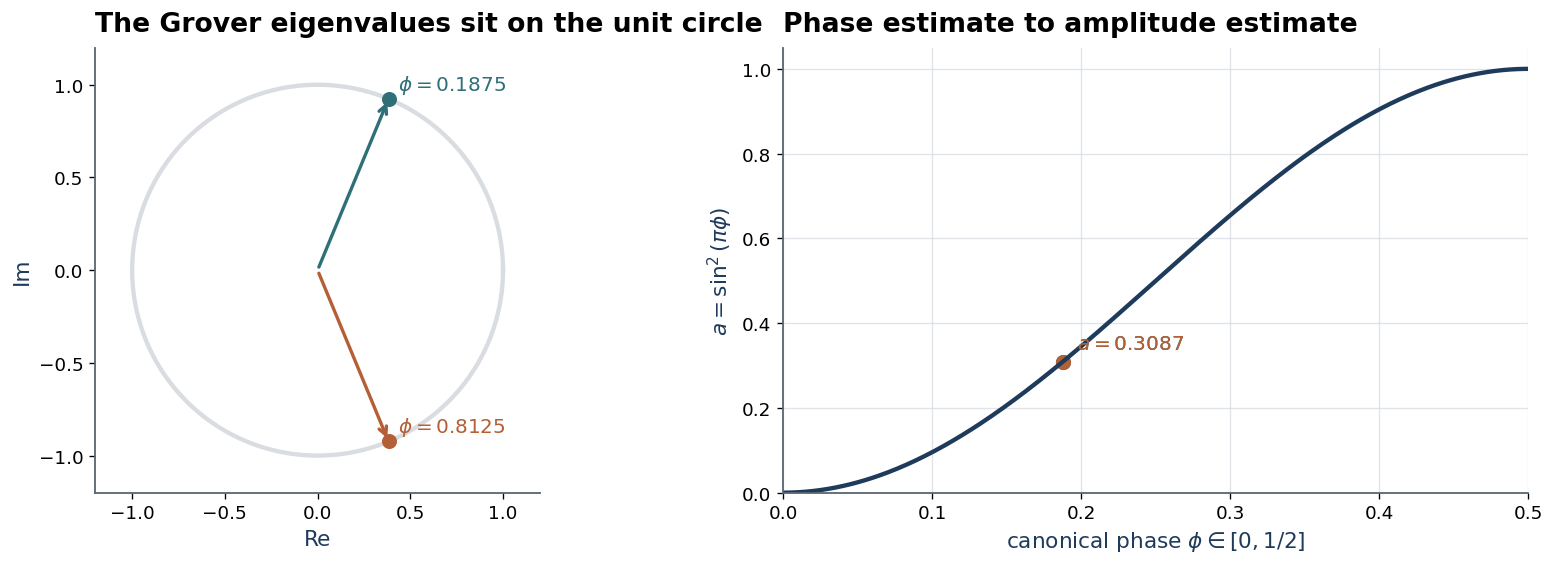

In [6]:
toy_eigenvalues, toy_eigenvectors = np.linalg.eig(Q_toy)
toy_phases = (np.angle(toy_eigenvalues) / (2 * np.pi)) % 1

phase_table = pd.DataFrame(
    {
        'eigenvalue': toy_eigenvalues,
        'phase phi': toy_phases,
        'decoded amplitude sin^2(pi phi)': np.sin(np.pi * np.minimum(toy_phases, 1 - toy_phases)) ** 2,
    }
).sort_values('phase phi').reset_index(drop=True)
display(phase_table)

phi_grid = np.linspace(0, 0.5, 400)
amplitude_grid = np.sin(np.pi * phi_grid) ** 2

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6), constrained_layout=True)

unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 600))
axes[0].plot(unit_circle.real, unit_circle.imag, color=COLORS['light_gray'])
for phase, color in zip(toy_phases, [COLORS['teal'], COLORS['rust']]):
    point = np.exp(2j * np.pi * phase)
    axes[0].annotate('', xy=(point.real, point.imag), xytext=(0, 0), arrowprops={'arrowstyle': '->', 'color': color, 'linewidth': 2.0})
    axes[0].plot(point.real, point.imag, 'o', color=color, markersize=8)
    axes[0].text(point.real + 0.05, point.imag + 0.05, fr'$\phi={phase:.4f}$', color=color)
axes[0].set_aspect('equal')
axes[0].set_xlim(-1.2, 1.2)
axes[0].set_ylim(-1.2, 1.2)
axes[0].set_xlabel('Re')
axes[0].set_ylabel('Im')
axes[0].set_title('The Grover eigenvalues sit on the unit circle', loc='left')
axes[0].grid(False)

axes[1].plot(phi_grid, amplitude_grid, color=COLORS['navy'])
for phase, color in zip(sorted(np.minimum(toy_phases, 1 - toy_phases)), [COLORS['teal'], COLORS['rust']]):
    amplitude = np.sin(np.pi * phase) ** 2
    axes[1].scatter([phase], [amplitude], color=color, s=65)
    axes[1].text(phase + 0.01, amplitude + 0.03, fr'$a={amplitude:.4f}$', color=color)
axes[1].set_xlabel(r'canonical phase $\phi \in [0, 1/2]$')
axes[1].set_ylabel(r'$a = \sin^2(\pi \phi)$')
axes[1].set_title('Phase estimate to amplitude estimate', loc='left')
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(0, 1.05)

plt.show()

This is the central conceptual move of QAE:

1. encode a probability into a state,
2. turn that probability into a Grover rotation angle,
3. read that angle with phase estimation,
4. convert the phase back into the original probability.

Lab 3 supplied step 3. QAE adds the amplitude-encoding and Grover-rotation pieces.

## 6. Full Toy QAE on a One-Qubit Example

**Concept question:** What does the complete amplitude-estimation circuit look like on the smallest nontrivial case?

We now build canonical, phase-estimation-based QAE explicitly.

Two useful input choices are:

- **exact Grover eigenstate**: gives one clean phase peak,
- **prepared state $A|0\rangle$**: gives the standard symmetric pair of peaks at $\phi$ and $1-\phi$.

Both lead to the same decoded amplitude.

,bitstring,probability,phase phi,canonical phase,decoded amplitude
0,0011,5.000000e-01,0.1875,0.1875,0.308658
1,1101,5.000000e-01,0.8125,0.1875,0.308658
2,0010,3.216724e-32,0.1250,0.1250,0.146447
3,0101,3.131436e-32,0.3125,0.3125,0.691342


,bitstring,probability,phase phi,canonical phase,decoded amplitude
0,0011,1.000000e+00,0.1875,0.1875,0.308658
1,0010,7.125804e-32,0.1250,0.1250,0.146447
2,0100,6.778695e-32,0.2500,0.2500,0.500000
3,1101,5.622020e-32,0.8125,0.1875,0.308658


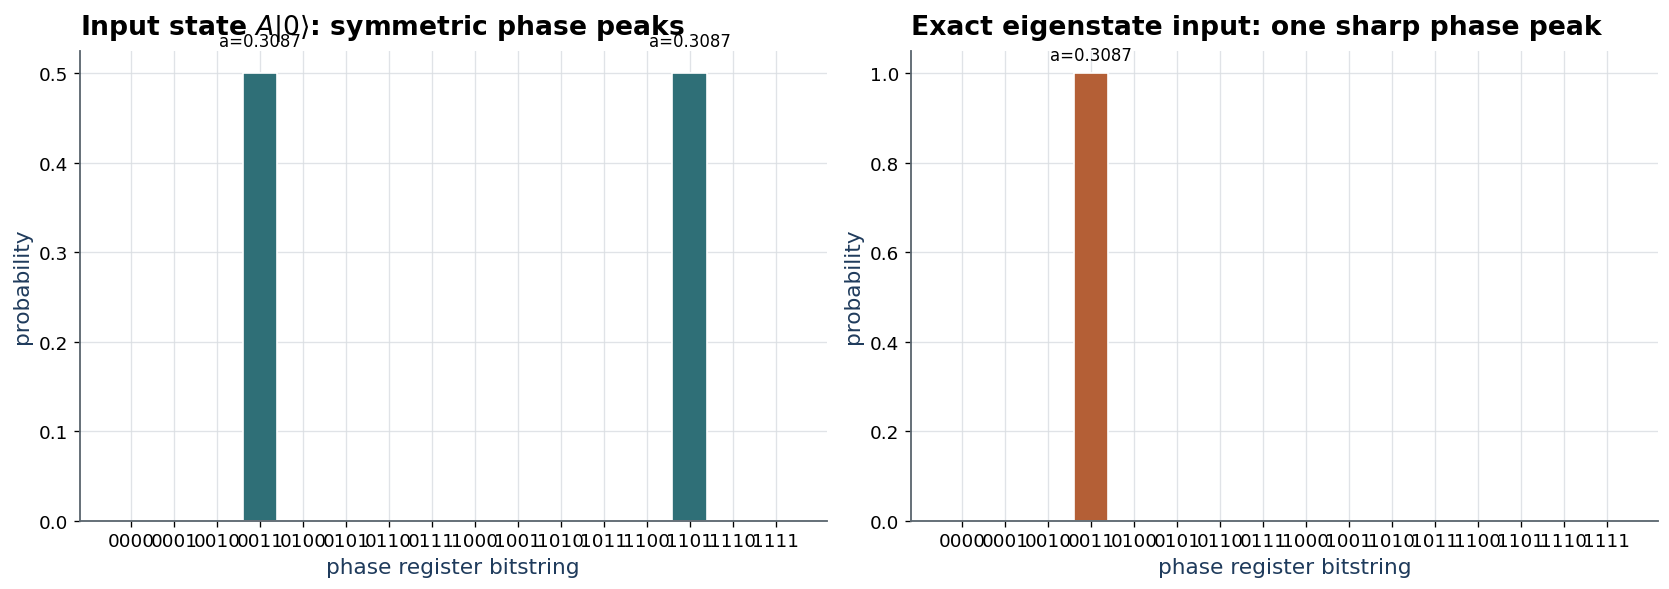

Exact encoded amplitude: 0.308658
Decoded from prepared-state peak 0011: 0.308658
Decoded from prepared-state peak 1101: 0.308658


In [7]:
def inverse_qft_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits, name=f'IQFT_{num_qubits}')
    for qubit in range(num_qubits // 2):
        qc.swap(qubit, num_qubits - qubit - 1)
    for target in reversed(range(num_qubits)):
        for control in reversed(range(target + 1, num_qubits)):
            qc.cp(-np.pi / (2 ** (control - target)), control, target)
        qc.h(target)
    return qc


def phase_register_distribution(statevector, phase_qubits):
    raw = statevector.probabilities_dict(qargs=list(reversed(range(phase_qubits))))
    return {str(bitstring): float(probability) for bitstring, probability in raw.items()}


def binary_to_phase(bitstring):
    return int(bitstring, 2) / (2 ** len(bitstring))


def canonical_phase(phase):
    return min(phase, 1 - phase)


def amplitude_from_phase(phase):
    return np.sin(np.pi * canonical_phase(phase)) ** 2


def unitary_gate_from_matrix(matrix, name):
    num_qubits = int(np.log2(matrix.shape[0]))
    qc = QuantumCircuit(num_qubits)
    qc.unitary(matrix, range(num_qubits))
    return qc.to_gate(label=name)


def build_phase_estimation_qae(system_gate, grover_matrix, phase_qubits, initial_system='prepared', eigenvector=None):
    system_qubits = system_gate.num_qubits
    total_qubits = phase_qubits + system_qubits
    qc = QuantumCircuit(total_qubits)

    for qubit in range(phase_qubits):
        qc.h(qubit)

    system_range = list(range(phase_qubits, total_qubits))
    if initial_system == 'prepared':
        qc.compose(system_gate, qubits=system_range, inplace=True)
    elif initial_system == 'eigenstate':
        qc.initialize(eigenvector / np.linalg.norm(eigenvector), system_range)
    else:
        raise ValueError('initial_system must be prepared or eigenstate')

    for qubit in range(phase_qubits):
        power = 2 ** (phase_qubits - 1 - qubit)
        powered_matrix = np.linalg.matrix_power(grover_matrix, power)
        powered_gate = unitary_gate_from_matrix(powered_matrix, name=f'Q^{power}')
        qc.append(powered_gate.control(1), [qubit, *system_range])

    qc.compose(inverse_qft_circuit(phase_qubits), qubits=range(phase_qubits), inplace=True)
    return qc


def top_phase_rows(distribution, top_k=6):
    rows = []
    for bitstring, probability in sorted(distribution.items(), key=lambda item: item[1], reverse=True)[:top_k]:
        phase = binary_to_phase(bitstring)
        rows.append(
            {
                'bitstring': bitstring,
                'probability': probability,
                'phase phi': phase,
                'canonical phase': canonical_phase(phase),
                'decoded amplitude': amplitude_from_phase(phase),
            }
        )
    return pd.DataFrame(rows)

phase_qubits_toy = 4
positive_phase_index = np.where((toy_phases > 0) & (toy_phases <= 0.5))[0][0]
positive_eigenvector = toy_eigenvectors[:, positive_phase_index]

qae_prepared_toy = build_phase_estimation_qae(A_toy, Q_toy, phase_qubits_toy, initial_system='prepared')
qae_eigen_toy = build_phase_estimation_qae(A_toy, Q_toy, phase_qubits_toy, initial_system='eigenstate', eigenvector=positive_eigenvector)

prepared_distribution = phase_register_distribution(Statevector.from_instruction(qae_prepared_toy), phase_qubits_toy)
eigen_distribution = phase_register_distribution(Statevector.from_instruction(qae_eigen_toy), phase_qubits_toy)

prepared_table = top_phase_rows(prepared_distribution, top_k=4)
eigen_table = top_phase_rows(eigen_distribution, top_k=4)

display(prepared_table)
display(eigen_table)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), constrained_layout=True)

prepared_bits = list(prepared_distribution.keys())
prepared_probs = [prepared_distribution[key] for key in prepared_bits]
axes[0].bar(prepared_bits, prepared_probs, color=COLORS['teal'], edgecolor='white')
axes[0].set_title(r'Input state $A|0\rangle$: symmetric phase peaks', loc='left')
axes[0].set_xlabel('phase register bitstring')
axes[0].set_ylabel('probability')
for bitstring in ['0011', '1101']:
    axes[0].text(bitstring, prepared_distribution[bitstring] + 0.03, f'a={amplitude_from_phase(binary_to_phase(bitstring)):.4f}', ha='center', fontsize=10)

eigen_bits = list(eigen_distribution.keys())
eigen_probs = [eigen_distribution[key] for key in eigen_bits]
axes[1].bar(eigen_bits, eigen_probs, color=COLORS['rust'], edgecolor='white')
axes[1].set_title('Exact eigenstate input: one sharp phase peak', loc='left')
axes[1].set_xlabel('phase register bitstring')
axes[1].set_ylabel('probability')
axes[1].text('0011', eigen_distribution['0011'] + 0.03, f'a={amplitude_from_phase(binary_to_phase("0011")):.4f}', ha='center', fontsize=10)

plt.show()

print(f'Exact encoded amplitude: {amplitude_a:.6f}')
print(f'Decoded from prepared-state peak 0011: {amplitude_from_phase(binary_to_phase("0011")):.6f}')
print(f'Decoded from prepared-state peak 1101: {amplitude_from_phase(binary_to_phase("1101")):.6f}')

This is the cleanest possible canonical-QAE demonstration.

- With an exact eigenstate input, phase estimation behaves exactly as in Lab 3.
- With the natural prepared state $A|0\rangle$, the output splits across the two conjugate Grover eigenphases.
- After the mapping $a = \sin^2(\pi\phi)$, both peaks decode to the same amplitude.

> **Takeaway:** The phase register never stores the probability directly. It stores a phase whose trigonometric image is the probability.

## 7. Finite-Scenario QAE for a Small Safety Problem

**Concept question:** Can we build a less abstract example that looks more like uncertainty evaluation?

Return to the eight-scenario toy model from Section 2. We now encode it coherently:

- three qubits hold the scenario label,
- a uniform superposition represents the equal uncertainty distribution,
- one flag qubit stores whether the scenario is safe.

The prepared state is

$$
A|0000\rangle = \frac{1}{\sqrt{8}} \sum_{x \in \{0,1\}^3} |x\rangle |f(x)\rangle,
$$

where $f(x)=1$ for the safe scenarios. Measuring the flag qubit alone would give the same safety probability $a=3/8$. QAE tries to infer that amplitude more efficiently than repeated direct sampling.

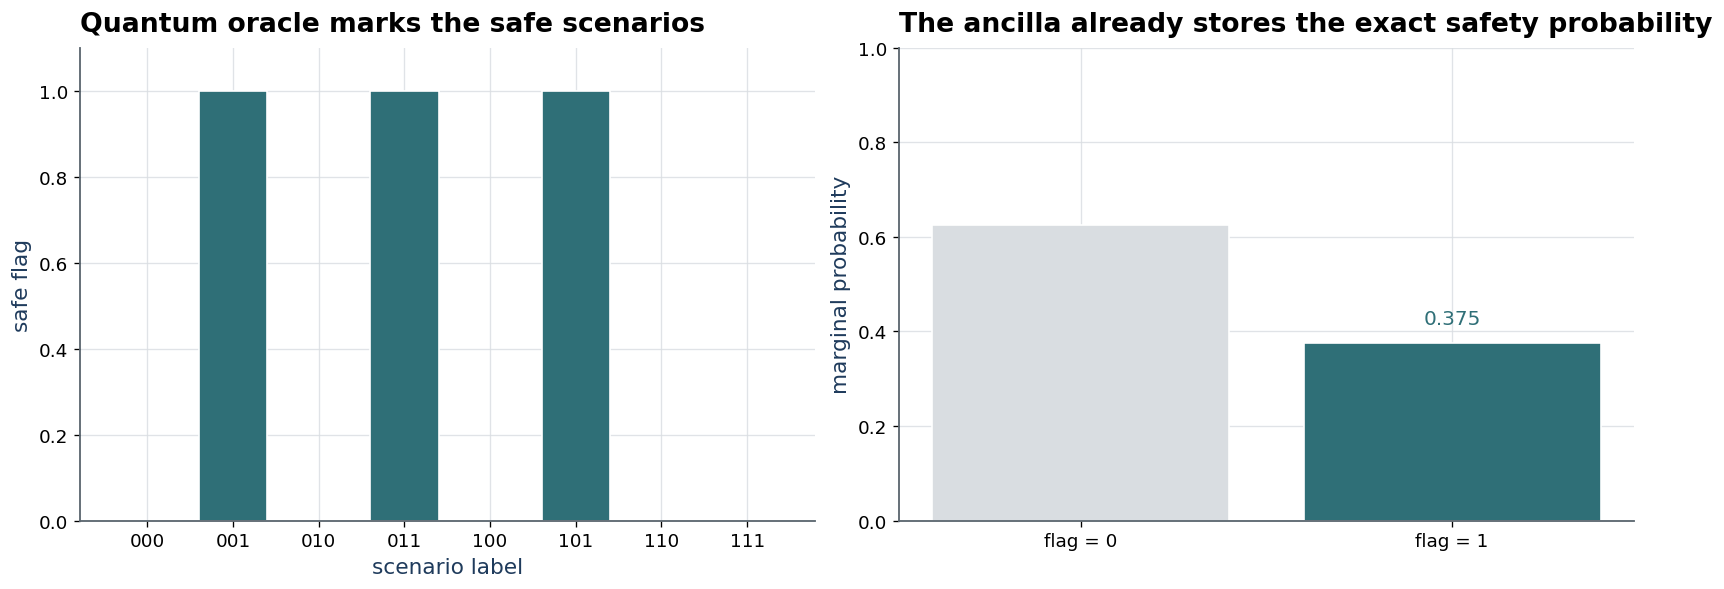

Exact safety probability from the state preparation circuit: 0.375000


In [8]:
safe_states = ['001', '011', '101']
exact_scenario_amplitude = len(safe_states) / 8

A_scenarios = QuantumCircuit(4, name='A_scen')
for qubit in range(3):
    A_scenarios.h(qubit)
for state in safe_states:
    for qubit, bit in enumerate(state):
        if bit == '0':
            A_scenarios.x(qubit)
    A_scenarios.mcx([0, 1, 2], 3)
    for qubit, bit in enumerate(state):
        if bit == '0':
            A_scenarios.x(qubit)

scenario_state = Statevector.from_instruction(A_scenarios)
flag_distribution = scenario_state.probabilities_dict(qargs=[3])
flag_probability = float(flag_distribution['1'])

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8), constrained_layout=True)
scenario_colors = [COLORS['teal'] if label in safe_states else COLORS['light_gray'] for label in scenario_labels]
axes[0].bar(scenario_labels, [1 if label in safe_states else 0 for label in scenario_labels], color=scenario_colors, edgecolor='white')
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel('scenario label')
axes[0].set_ylabel('safe flag')
axes[0].set_title('Quantum oracle marks the safe scenarios', loc='left')

axes[1].bar(['flag = 0', 'flag = 1'], [1 - flag_probability, flag_probability], color=[COLORS['light_gray'], COLORS['teal']], edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('marginal probability')
axes[1].set_title('The ancilla already stores the exact safety probability', loc='left')
axes[1].text(1, flag_probability + 0.04, f'{flag_probability:.3f}', ha='center', color=COLORS['teal'])

plt.show()

print(f'Exact safety probability from the state preparation circuit: {flag_probability:.6f}')

,phase qubits,dominant bitstring,dominant phase,decoded amplitude,absolute error,largest peak probability
0,4,1101,0.812500,0.308658,0.066342,0.325183
1,5,11001,0.781250,0.402455,0.027455,0.378871
2,6,110011,0.796875,0.354858,0.020142,0.264318
3,7,0011011,0.210938,0.378510,0.003510,0.465203


,bitstring,probability,phase phi,canonical phase,decoded amplitude
0,0011011,0.465203,0.210938,0.210938,0.378510
1,1100101,0.465203,0.789062,0.210938,0.378510
2,0011010,0.013948,0.203125,0.203125,0.354858
3,1100110,0.013948,0.796875,0.203125,0.354858
4,0011100,0.007700,0.218750,0.218750,0.402455
5,1100100,0.007700,0.781250,0.218750,0.402455
6,1100111,0.002960,0.804688,0.195312,0.331555
7,0011001,0.002960,0.195312,0.195312,0.331555


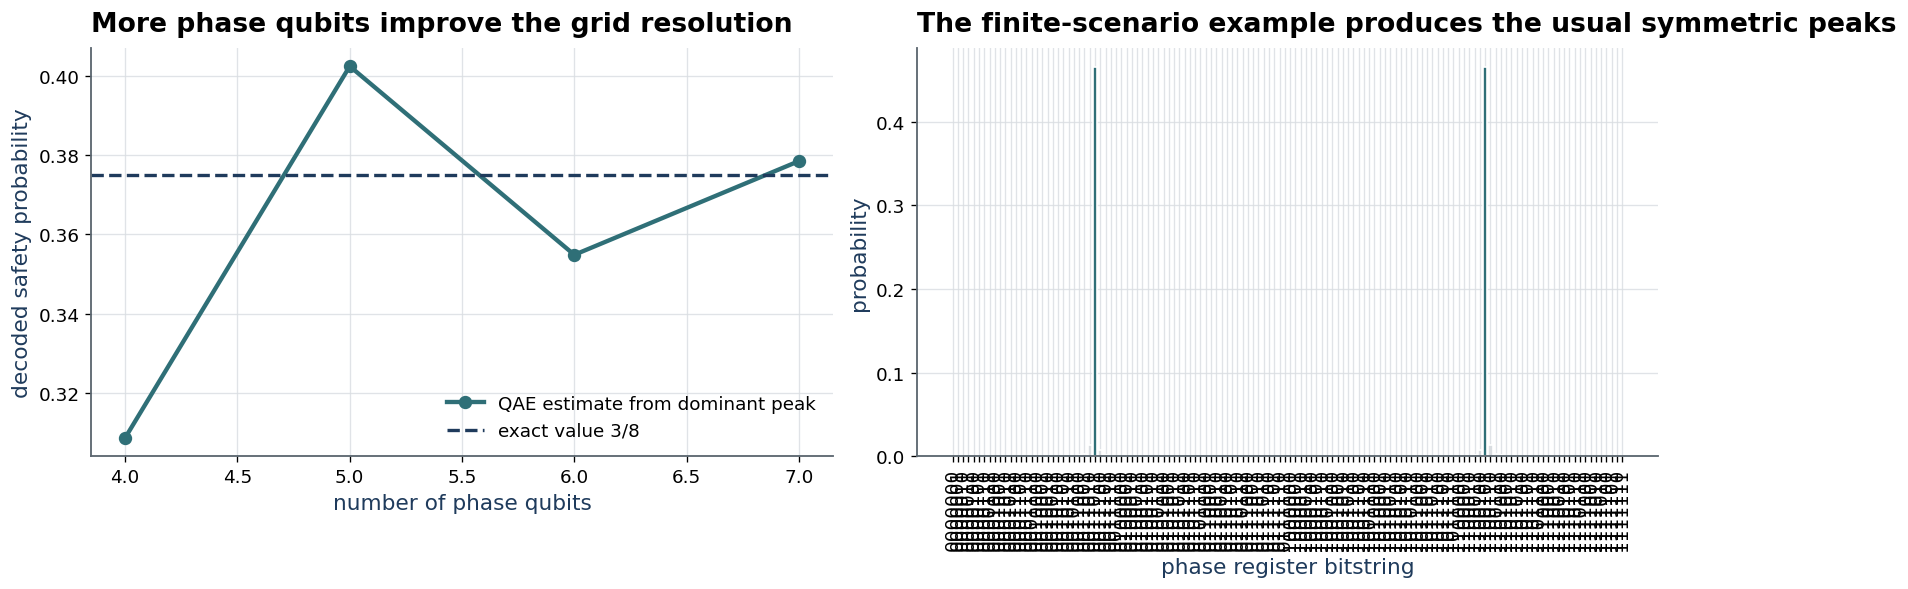

Exact safety probability: 0.375000
Best 7-qubit dominant-peak QAE estimate: 0.378510


In [9]:
Q_scenarios = grover_operator_from_state_preparation(A_scenarios, good_qubits=[3])

phase_qubit_choices = [4, 5, 6, 7]
rows = []
for phase_qubits in phase_qubit_choices:
    qae_circuit = build_phase_estimation_qae(A_scenarios, Q_scenarios, phase_qubits, initial_system='prepared')
    distribution = phase_register_distribution(Statevector.from_instruction(qae_circuit), phase_qubits)
    top_bitstring = max(distribution, key=distribution.get)
    top_phase = binary_to_phase(top_bitstring)
    estimate = amplitude_from_phase(top_phase)
    rows.append(
        {
            'phase qubits': phase_qubits,
            'dominant bitstring': top_bitstring,
            'dominant phase': top_phase,
            'decoded amplitude': estimate,
            'absolute error': abs(estimate - exact_scenario_amplitude),
            'largest peak probability': distribution[top_bitstring],
        }
    )

scenario_qae_table = pd.DataFrame(rows)
display(scenario_qae_table)

best_phase_qubits = 7
best_circuit = build_phase_estimation_qae(A_scenarios, Q_scenarios, best_phase_qubits, initial_system='prepared')
best_distribution = phase_register_distribution(Statevector.from_instruction(best_circuit), best_phase_qubits)
best_table = top_phase_rows(best_distribution, top_k=8)
display(best_table)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8), constrained_layout=True)

axes[0].plot(scenario_qae_table['phase qubits'], scenario_qae_table['decoded amplitude'], marker='o', color=COLORS['teal'], label='QAE estimate from dominant peak')
axes[0].axhline(exact_scenario_amplitude, color=COLORS['navy'], linestyle='--', linewidth=2.0, label='exact value 3/8')
axes[0].set_xlabel('number of phase qubits')
axes[0].set_ylabel('decoded safety probability')
axes[0].set_title('More phase qubits improve the grid resolution', loc='left')
axes[0].legend(loc='lower right')

bitstrings = list(best_distribution.keys())
probabilities = [best_distribution[key] for key in bitstrings]
highlight_bits = set(best_table.head(2)['bitstring'])
bar_colors = [COLORS['teal'] if key in highlight_bits else COLORS['light_gray'] for key in bitstrings]
axes[1].bar(bitstrings, probabilities, color=bar_colors, edgecolor='white')
axes[1].set_xlabel('phase register bitstring')
axes[1].set_ylabel('probability')
axes[1].set_title('The finite-scenario example produces the usual symmetric peaks', loc='left')
axes[1].tick_params(axis='x', rotation=90)

plt.show()

print(f'Exact safety probability: {exact_scenario_amplitude:.6f}')
print(f'Best 7-qubit dominant-peak QAE estimate: {scenario_qae_table.iloc[-1]["decoded amplitude"]:.6f}')

This example is small enough that we can see everything explicitly.

- The uncertainty model is the uniform superposition over eight scenarios.
- The safety predicate is the reversible marking of the flag qubit.
- The QAE estimate improves as the phase grid becomes finer.

The estimate is not exact here because $3/8$ does not correspond to a phase with a short terminating binary expansion. That is a useful lesson, not a defect: finite precision is part of the real algorithmic story.

## 8. Encoding Expectations, Not Only Binary Success

**Concept question:** What if the target is an average score instead of a yes/no probability?

This matters for practical applications such as risk scoring or path-quality evaluation. Suppose each scenario has a bounded score in $[0,1]$:

$$
q(00)=0.05,
\quad
q(01)=0.35,
\quad
q(10)=0.65,
\quad
q(11)=0.95.
$$

We can still encode the mean into an ancilla amplitude by using controlled rotations:

$$
|x\rangle|0\rangle \mapsto |x\rangle\left(\sqrt{1-q(x)}\,|0\rangle + \sqrt{q(x)}\,|1\rangle\right).
$$

Then the ancilla success probability is exactly the average score.

,scenario,score q(x),rotation angle 2 arcsin(sqrt(q(x)))
0,00,0.05,0.451027
1,01,0.35,1.266104
2,10,0.65,1.875489
3,11,0.95,2.690566


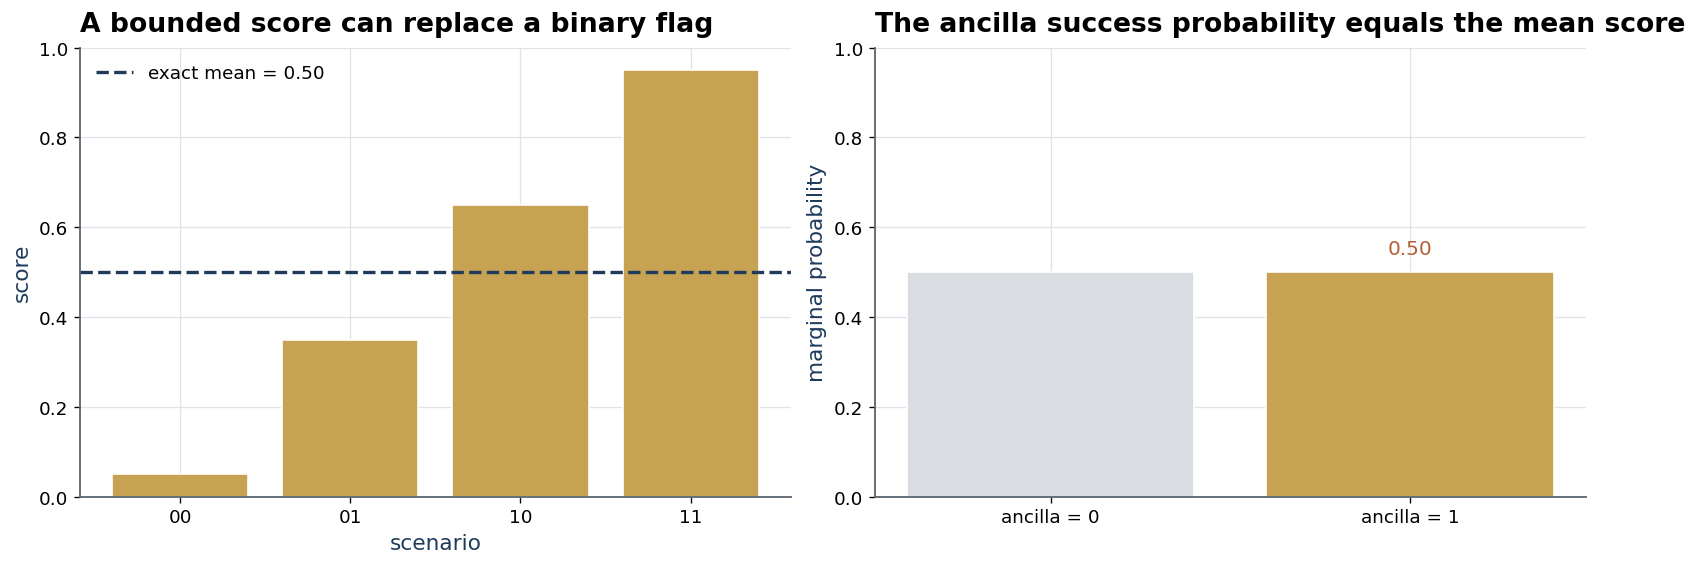

Exact mean score: 0.500000
Encoded ancilla success probability: 0.500000


In [10]:
score_map = {
    '00': 0.05,
    '01': 0.35,
    '10': 0.65,
    '11': 0.95,
}
exact_mean_score = np.mean(list(score_map.values()))

A_scores = QuantumCircuit(3, name='A_score')
A_scores.h(0)
A_scores.h(1)

for state, score in score_map.items():
    angle = 2 * np.arcsin(np.sqrt(score))
    for qubit, bit in enumerate(state):
        if bit == '0':
            A_scores.x(qubit)
    controlled_rotation = QuantumCircuit(1)
    controlled_rotation.ry(angle, 0)
    A_scores.append(controlled_rotation.to_gate(label=f'Ry({angle:.2f})').control(2), [0, 1, 2])
    for qubit, bit in enumerate(state):
        if bit == '0':
            A_scores.x(qubit)

score_state = Statevector.from_instruction(A_scores)
score_flag_distribution = score_state.probabilities_dict(qargs=[2])
encoded_mean_score = float(score_flag_distribution['1'])

score_table = pd.DataFrame(
    {
        'scenario': list(score_map.keys()),
        'score q(x)': list(score_map.values()),
        'rotation angle 2 arcsin(sqrt(q(x)))': [2 * np.arcsin(np.sqrt(value)) for value in score_map.values()],
    }
)
display(score_table)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), constrained_layout=True)
axes[0].bar(list(score_map.keys()), list(score_map.values()), color=COLORS['gold'], edgecolor='white')
axes[0].axhline(exact_mean_score, color=COLORS['navy'], linestyle='--', linewidth=2.0, label=f'exact mean = {exact_mean_score:.2f}')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('scenario')
axes[0].set_ylabel('score')
axes[0].set_title('A bounded score can replace a binary flag', loc='left')
axes[0].legend(loc='upper left')

axes[1].bar(['ancilla = 0', 'ancilla = 1'], [1 - encoded_mean_score, encoded_mean_score], color=[COLORS['light_gray'], COLORS['gold']], edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('marginal probability')
axes[1].set_title('The ancilla success probability equals the mean score', loc='left')
axes[1].text(1, encoded_mean_score + 0.04, f'{encoded_mean_score:.2f}', ha='center', color=COLORS['rust'])

plt.show()

print(f'Exact mean score: {exact_mean_score:.6f}')
print(f'Encoded ancilla success probability: {encoded_mean_score:.6f}')

This is the version most relevant to finance-style payoffs, risk metrics, and expected path quality:

- binary success probabilities are only one special case,
- bounded expectations can also be mapped into amplitudes,
- once the mapping exists, the same amplitude-estimation logic can be applied.

In larger applications, this controlled-rotation stage is often one of the hardest parts of the whole algorithm.

## 9. Summary and Practical Interpretation

This lab followed one continuous arc:

- Monte Carlo estimation motivated the problem,
- a one-qubit state-preparation circuit encoded a probability into an amplitude,
- the Grover operator turned that amplitude into a rotation angle,
- phase estimation recovered the angle,
- the decoded phase reproduced the original probability,
- a finite-scenario example showed the same logic in a safety-estimation setting,
- a score-encoding example showed how expectations fit the same framework.

**Important caveats**

- The quadratic query improvement is real only relative to the number of oracle uses.
- State preparation and reversible scoring may dominate the real cost.
- Canonical QAE needs coherent controlled powers of the Grover operator, so circuit depth grows quickly.
- On near-term hardware, the toy logic is much easier than realistic deployment.

> **Final takeaway:** QAE is best understood as **phase estimation applied to a Grover rotation whose angle encodes the target probability or expectation**. If that angle can be prepared and queried efficiently, the asymptotic advantage over Monte Carlo becomes meaningful.